In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cmocean
import seaborn as sns

In [2]:
plt.style.use("~/nice.mplstyle")

In [3]:
import pandas as pd
import io
import matplotlib.dates as mdates

In [5]:
csv_fss="""FHR006,,,
Amount (mm),GFS,HRRR,Nested-EAGLE
1,0.702,0.707,0.727
2,0.670,0.680,0.690
5,0.578,0.617,0.589
10,0.436,0.523,0.448
20,0.243,0.376,0.244
25,0.184,0.320,0.182
30,0.140,0.274,0.134
40,0.077,0.200,0.072
50,0.043,0.138,0.042
60,0.026,0.101,0.028
70,0.019,0.078,0.017
75,0.017,0.068,0.016
80,0.013,0.057,0.011
90,0.013,0.045,0.005
100,0.011,0.037,0.002
FHR24,,,
Amount (mm),GFS,HRRR,Nested-EAGLE
1,0.656,0.651,0.664
2,0.609,0.610,0.610
5,0.494,0.521,0.484
10,0.348,0.416,0.323
20,0.182,0.265,0.141
25,0.135,0.214,0.092
30,0.103,0.175,0.059
40,0.052,0.118,0.023
50,0.026,0.079,0.010
60,0.013,0.052,0.004
70,0.009,0.037,0.000
75,0.007,0.031,0.000
80,0.007,0.027,0.000
90,0.004,0.018,0.000
100,0.005,0.017,0.000"""

In [126]:
def csv2fds(csvdata, rename_dict=None, nrows=15):

    csv_file = io.StringIO(csvdata)

    # Read the first table (FHR006) into a pandas DataFrame.
    # We skip the header row and read 15 rows of data.
    df_fhr6 = pd.read_csv(csv_file, skiprows=1, nrows=nrows)
    if rename_dict is not None:
        df_fhr6.rename(columns=rename_dict, inplace=True)
    df_fhr6['fhr'] = 6
    
    # Reset the file pointer to the beginning to read the second table.
    csv_file.seek(0)
    
    # Read the second table (FHR24). We skip to the correct row.
    df_fhr24 = pd.read_csv(csv_file, skiprows=nrows+3, nrows=nrows)
    if rename_dict is not None:
        df_fhr24.rename(columns=rename_dict, inplace=True)
    df_fhr24['fhr'] = 24
    
    # Concatenate the two DataFrames into a single one.
    df_combined = pd.concat([df_fhr6, df_fhr24])
    
    # Set the 'amount' and 'fhr' columns as the index. This is a crucial
    # step to define the dimensions for the xarray dataset.
    if rename_dict is not None:
        y = next(iter(rename_dict.values()))
    else:
        y = df_fhr24.columns.tolist()[0]
    if y == "time":
        df_combined['time'] = pd.to_datetime(df_combined['time'])
    df_combined = df_combined.set_index([y, 'fhr'])
    
    # Convert the pandas DataFrame to an xarray Dataset.
    return xr.Dataset.from_dataframe(df_combined)


In [29]:
#fds = csv2fds(csv_fss), {})#{'Amount (mm)': 'amount'})
fds = csv2fds(csv_fss)

In [67]:
def up_arrow(ax):
    
    ax.annotate(
        "",
        xy=(1.05, 0.25),  # Arrowhead position (bottom-right of plot area)
        xytext=(1.05, 0.75), # Text position (above the arrowhead)
        xycoords='axes fraction', # Use axes coordinates for positioning
        textcoords='axes fraction', # Use axes coordinates for positioning
        arrowprops=dict(
            arrowstyle="<-",
            connectionstyle="arc3",
            color="black",
            lw=4,
        ),
        ha='center', # Horizontal alignment of the text
        va='center', # Vertical alignment of the text
        rotation=90 # Rotate the text by 90 degrees
    )
    ax.text(
        1.15,
        .5,
        "Higher is Better",
        rotation=90,
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
    return ax

In [85]:
def make_plot(xds, metric, xlabel = None):
    if xlabel is None:
        xlabel = list(xds.dims.keys())[0]
    ncols = 2
    fig, axs = plt.subplots(1, ncols, figsize=(10, 5), constrained_layout=True, sharex=True, sharey=True)
    
    handles = []
    labels = []
    for fhr, ax in zip(xds.fhr.values, axs):
        lastcol = ax.get_subplotspec().is_last_col()
        for label in ["Nested-EAGLE", "HRRR", "GFS"]:
        
            plotme = xds[label].sel(fhr=fhr)
            plotme.plot(ax=ax, label=label)

        title = f"Lead Time = {fhr}h"
        ax.set(
            xlabel=xlabel,
            xlim=[0,100],
            xticks=np.arange(0, 101, 20),
            title=title,
            ylabel=f"{metric} vs AORC" if ax.get_subplotspec().is_first_col() else "",
        )

        if metric.lower() == "fss":
            ax.set(
                yticks=np.arange(9)/10,
                ylim=[0, .8]
            )
            if ax.get_subplotspec().is_last_col():
                ax = up_arrow(ax)
        if len(handles) == 0:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        
    legend = fig.legend(
        handles,
        labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        ncols=len(labels),
        frameon=False,
    )
    for line in legend.get_lines():
        line.set_linewidth(16)
    plt.tight_layout(pad=.15, rect=[0, 0.1, 1, 1])
    return fig, axs

/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/2710056663.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  xlabel = list(xds.dims.keys())[0]
/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/2710056663.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=.15, rect=[0, 0.1, 1, 1])


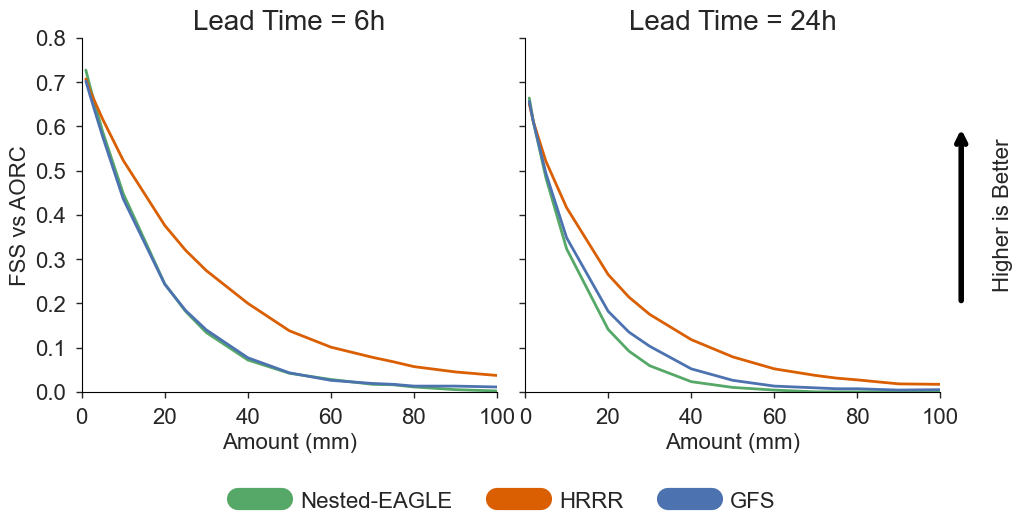

In [76]:
fig, axs = make_plot(fds, "FSS")
[
    ax.set(
    )
    for ax in axs
];

fig.savefig("figures-precip/fss_threshold_conus.jpeg", bbox_inches="tight", dpi=300)
fig.savefig("figures-precip/fss_threshold_conus.pdf", bbox_inches="tight")

In [77]:
csv_fsst="""FHR006,,,
Percentile,GFS,HRRR,Nested-EAGLE
5,0.730,0.754,0.758
10,0.720,0.751,0.756
25,0.706,0.747,0.752
50,0.686,0.733,0.736
75,0.636,0.696,0.696
90,0.558,0.632,0.628
95,0.486,0.576,0.562
99,0.305,0.415,0.372
99.9,0.116,0.208,0.167
FHR24,,,
Percentile,GFS,HRRR,Nested-EAGLE
5,0.710,0.681,0.724
10,0.700,0.677,0.721
25,0.684,0.664,0.711
50,0.653,0.635,0.682
75,0.583,0.575,0.616
90,0.479,0.495,0.522
95,0.397,0.434,0.444
99,0.228,0.280,0.269
99.9,0.086,0.128,0.114"""

In [78]:
tds = csv2fds(csv_fsst, nrows=9)

/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/2710056663.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  xlabel = list(xds.dims.keys())[0]
/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/2710056663.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=.15, rect=[0, 0.1, 1, 1])


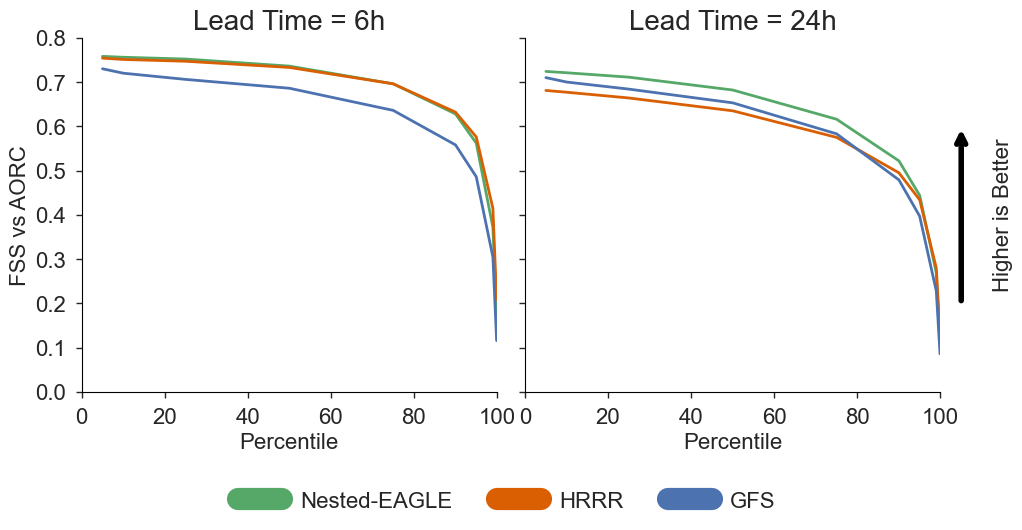

In [79]:
fig, axs = make_plot(tds, "FSS")
[ax.set(ylim=[0, 0.8], yticks=np.arange(9)/10) for ax in axs];

fig.savefig("figures-precip/fss_percentile_conus.jpeg", bbox_inches="tight", dpi=300)
fig.savefig("figures-precip/fss_percentile_conus.pdf", bbox_inches="tight")

In [80]:
csv_bias="""FHR006,,,
Amount (mm),GFS,HRRR,Nested-EAGLE
1,1.217,0.734,0.964
2,1.128,0.747,0.878
5,0.938,0.771,0.727
10,0.758,0.793,0.595
20,0.611,0.867,0.454
25,0.579,0.927,0.412
30,0.555,1.008,0.378
40,0.505,1.176,0.323
50,0.458,1.354,0.289
60,0.404,1.513,0.229
70,0.396,1.640,0.175
75,0.385,1.700,0.161
80,0.392,1.786,0.148
90,0.380,1.843,0.116
100,0.341,1.848,0.086
FHR24,,,
Amount (mm),GFS,HRRR,Nested-EAGLE
1,1.212,0.985,0.994
2,1.135,1.005,0.884
5,0.973,1.052,0.700
10,0.810,1.092,0.533
20,0.671,1.149,0.345
25,0.648,1.206,0.273
30,0.642,1.280,0.227
40,0.611,1.414,0.147
50,0.573,1.544,0.085
60,0.500,1.618,0.039
70,0.443,1.676,0.014
75,0.398,1.697,0.008
80,0.380,1.740,0.004
90,0.384,1.795,0.000
100,0.415,1.876,0.000"""

In [81]:
bds = csv2fds(csv_bias)

/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/3968075630.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  xlabel = list(xds.dims.keys())[0]
/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/3968075630.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=.15, rect=[0, 0.1, 1, 1])


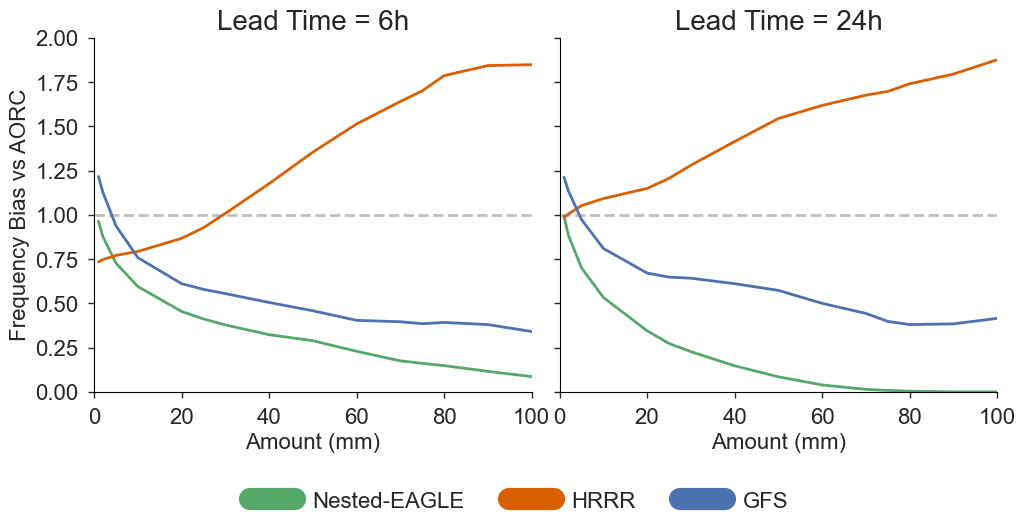

In [96]:
fig, axs = make_plot(bds, "Frequency Bias")
for ax in axs:
    ax.axhline(y=1, color="gray", linestyle="--", alpha=.5)
    ax.set(ylim=[0, 1.75], yticks=np.arange(0, 201, 25)/100)
    
fig.savefig("figures-precip/frequency_bias_amount_conus.jpeg", bbox_inches="tight", dpi=300)
fig.savefig("figures-precip/frequency_bias_amount_conus.pdf", bbox_inches="tight")

In [117]:
csv_mmeans="""FHR006,,,,
Month,AORC,GFS,HRRR,Nested-EAGLE
Feb 2023,0.421,0.483,0.398,0.371
Mar 2023,0.555,0.634,0.504,0.481
Apr 2023,0.482,0.576,0.432,0.413
May 2023,0.525,0.571,0.359,0.358
June 2023,0.629,0.616,0.410,0.428
Jul 2023,0.582,0.500,0.388,0.403
Aug 2023,0.605,0.509,0.404,0.411
Sep 2023,0.441,0.385,0.293,0.310
Oct 2023,0.456,0.435,0.371,0.369
Nov 2023,0.322,0.332,0.273,0.259
Dec 2023,0.451,0.445,0.401,0.386
Jan 2024,0.619,0.662,0.569,0.531
FHR024,,,,
Month,AORC,GFS,HRRR,Nested-EAGLE
Feb 2023,0.422,0.492,0.512,0.380
Mar 2023,0.555,0.642,0.652,0.477
Apr 2023,0.482,0.602,0.572,0.412
May 2023,0.525,0.597,0.504,0.328
June 2023,0.629,0.628,0.578,0.404
Jul 2023,0.582,0.530,0.561,0.373
Aug 2023,0.605,0.522,0.568,0.395
Sep 2023,0.441,0.389,0.427,0.298
Oct 2023,0.456,0.435,0.490,0.369
Nov 2023,0.322,0.337,0.365,0.260
Dec 2023,0.451,0.452,0.500,0.390
Jan 2024,0.605,0.646,0.690,0.533"""

In [127]:
mds = csv2fds(csv_mmeans, rename_dict={"Month": "time"}, nrows=12)

/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/897979449.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_combined['time'] = pd.to_datetime(df_combined['time'])


/var/folders/0k/gh0lwxg17l1_fbtvplvt45s40000gp/T/ipykernel_60777/4294459309.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])


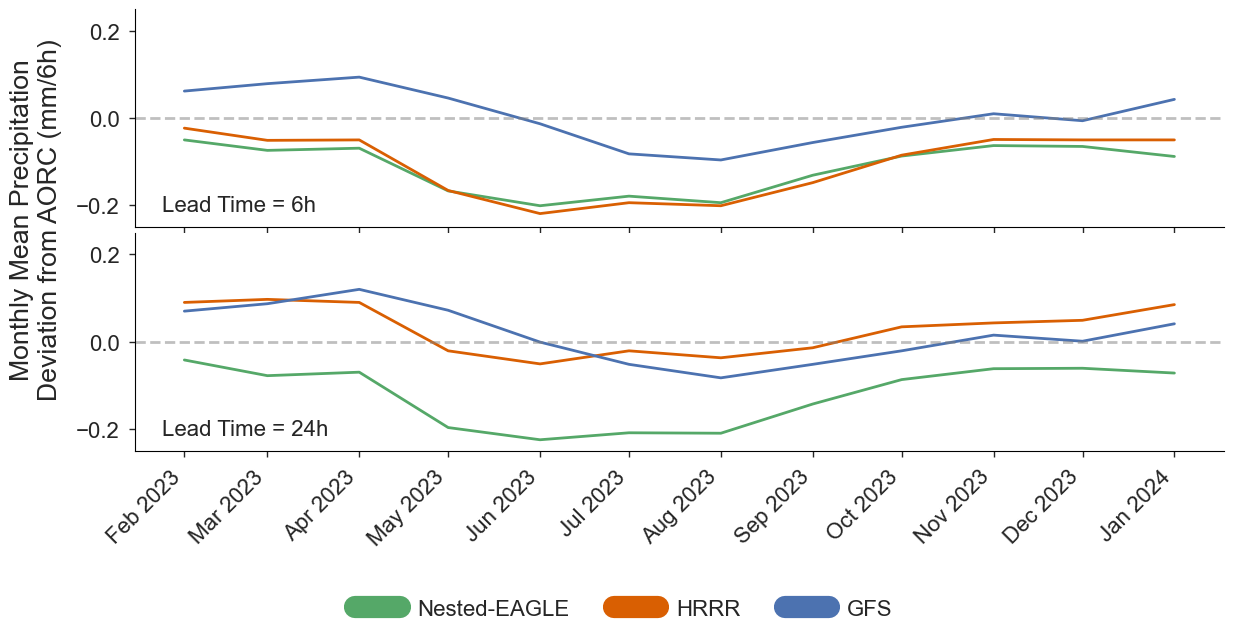

In [142]:
nrows = 2
fig, axs = plt.subplots(nrows, 1, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)

handles = []
labels = []

for fhr, ax in zip(mds.fhr.values, axs):
    for label in ["Nested-EAGLE", "HRRR", "GFS"]:
    
        kw = {"color": "black"} if label == "AORC" else {}
        plotme = mds[label].sel(fhr=fhr)
        plotme = plotme - mds["AORC"].sel(fhr=fhr)
        plotme.plot(ax=ax, label=label, **kw)
    ax.set(
        xlabel="",
        xticks=plotme.time.values,
        ylim=[-.25, .25],
        title="",
#        ylabel="Monthly Mean Precip Deviation from AORC (mm)",
    )
    ax.text(.025, .1, f"Lead Time = {fhr}h", transform=ax.transAxes, ha="left", va="center")
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %Y"),
    )
    ax.axhline(y=0, color="gray", linestyle="--", alpha=.5)
    plt.xticks(rotation=45, ha="right")
    if len(handles) == 0:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        
legend = fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncols=len(labels),
    frameon=False,
)
for line in legend.get_lines():
    line.set_linewidth(16)
    
fig.supylabel(
    "Monthly Mean Precipitation\nDeviation from AORC (mm/6h)",
    ha="center",
    va="center",
    position=(.01, .65),
)
plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])
fig.savefig("figures-precip/monthly_means_conus.jpeg", bbox_inches="tight", dpi=300)
fig.savefig("figures-precip/monthly_means_conus.pdf", bbox_inches="tight")